# Benchmark notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install jupyter notebook tensorboard loguru matplotlib numpy opencv-python pandas pandas_path pillow pyproj pytorch_lightning rasterio scikit-learn segmentation-models-pytorch torch torchvision tqdm transformers typer xarray xarray-spatial --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%env HF_ENDPOINT=https://hf-mirror.com

env: HF_ENDPOINT=https://hf-mirror.com


In [4]:
import rasterio

from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import torch

import warnings
warnings.filterwarnings("ignore")

print(torch.__version__)

if torch.cuda.is_available():
    print(torch.version.cuda)
    print(torch.cuda.get_device_capability())
    x = torch.tensor([1.0, 2.0]).cuda()
    print(x + x)

2.12.1+cpu


## Explore the data

Data directory contents:
```
.
├── data
│   ├── images
│   │   ├── train_chip_id_1
│   │   │   ├── B02.tif
│   │   │   ├── B03.tif
│   │   │   ├── B04.tif
│   │   │   └── B08.tif
│   │   └── ... 
│   ├── labels
│   │   ├── train_chip_id_1.tif
│   │   └── ... 
└────── metadata
        ├── train_metadata.csv
        └── ...
```

In [5]:
metadata_dir = Path.cwd().parent.parent.parent.resolve() / Path("data/GF1_B02_B03_B04_B08_Mask")
metadata_path = metadata_dir / "metadata.csv"
df = pd.read_csv(metadata_path)

def update_path(row):
    file_suffix = ".tif"
    filename = row["filename"] + file_suffix
    path = os.path.join(metadata_dir, filename)
    return path

df["path"] = df.apply(update_path, axis=1)
df.head(10)

,filename,location,datetime,path
0,GF1_WFV1_E102.0_N28.0_20140302_L2A0000280476,E102.0-N28.0,2014/3/2,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
1,GF1_WFV1_E104.1_S0.6_20151012_L2A0001096133,E104.1-S0.6,2015/10/12,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
2,GF1_WFV1_E104.3_N12.9_20140522_L2A0000356326,E104.3-N12.9,2014/5/22,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
3,GF1_WFV1_E104.8_N51.3_20150617_L2A0000979951,E104.8-N51.3,2015/6/17,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
4,GF1_WFV1_E114.4_N38.0_20130505_L2A0000029007,E114.4-N38.0,2013/5/5,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
5,GF1_WFV1_E115.1_N49.6_20140423_L2A0000314913,E115.1-N49.6,2014/4/23,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
6,GF1_WFV1_E116.5_N19.6_20130508_L2A0000022031,E116.5-N19.6,2013/5/8,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
7,GF1_WFV1_E119.1_N36.3_20131118_L2A0000117883,E119.1-N36.3,2013/11/18,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
8,GF1_WFV1_E120.2_N53.0_20150705_L2A0000939154,E120.2-N53.0,2015/7/5,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...
9,GF1_WFV1_E124.1_N49.6_20130516_L2A0000022014,E124.1-N49.6,2013/5/16,C:\Users\gaoha\PycharmProjects\cloud\data\GF1_...


In [6]:
TRAIN_FEATURES = Path.cwd().parent.parent.parent.resolve() / Path("data/metadata")
TEST_FEATURES = TRAIN_FEATURES
assert TRAIN_FEATURES.exists()

### Metadata

Let's start by looking at the metadata for the train set, to understand what the images in this capture.

In [7]:
csv_files = list(TRAIN_FEATURES.glob("*metadata.csv"))
csv_files

[WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/GF1_WFV1_E102.0_N28.0_20140302_L2A0000280476_metadata.csv'),
 WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/HRC_WHU_metadata.csv'),
 WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/l8cloudmasks_metadata.csv'),
 WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/oncloudn_metadata.csv'),
 WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/RICE2_metadata.csv')]

In [8]:
training_targets_txt = TRAIN_FEATURES / "training_targets.txt"
with open(training_targets_txt, 'r', encoding='utf-8') as f:
    training_targets = [line.strip() for line in f if line.strip()]
training_targets

['l8cloudmasks',
 'RICE2',
 'GF1_WFV4_W100.3_N45.1_20140522_L2A0000244682',
 'GF1_WFV1_W158.9_N21.3_20160806_L2A0001750182',
 'GF1_WFV4_E126.2_N30.2_20160817_L2A0001769953',
 'GF1_WFV4_E139.5_N35.2_20140407_L2A0000966128',
 'GF1_WFV1_E82.2_N44.7_20130803_L2A0000118101',
 'GF1_WFV4_E114.9_N23.5_20141008_L2A0000508173',
 'GF1_WFV4_E109.6_N18.5_20140510_L2A0000286067',
 'GF1_WFV4_E111.3_N30.2_20150506_L2A0000895933',
 'GF1_WFV1_E68.0_N57.9_20130705_L2A0000356197',
 'GF1_WFV4_W97.5_N38.5_20140517_L2A0000244685',
 'GF1_WFV1_E120.2_N53.0_20150705_L2A0000939154',
 'GF1_WFV4_E121.6_N23.5_20140130_L2A0000417191',
 'GF1_WFV4_W84.3_N38.5_20140523_L2A0000356168',
 '!GF1_WFV1_W62.5_S10.6_20140610_L2A0000253147',
 'GF1_WFV1_W59.9_S17.4_20140528_L2A0000238651',
 'GF1_WFV1_W50.9_S17.4_20140506_L2A0000227311',
 'GF1_WFV4_E107.0_N30.2_20130929_L2A0000139657',
 'GF1_WFV1_E115.1_N49.6_20140423_L2A0000314913',
 'GF1_WFV4_W56.8_S10.1_20140610_L2A0000253154',
 'GF1_WFV4_W67.3_N18.5_20140801_L2A0000292229',
 

In [9]:
selected_csv_files = [csv_file for csv_file in csv_files if csv_file.name.replace("_metadata.csv", "") in training_targets]
selected_csv_files

[WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/GF1_WFV1_E102.0_N28.0_20140302_L2A0000280476_metadata.csv'),
 WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/l8cloudmasks_metadata.csv'),
 WindowsPath('C:/Users/gaoha/PycharmProjects/cloud/data/metadata/RICE2_metadata.csv')]

In [10]:
df_list = []

for x in selected_csv_files:
    df = pd.read_csv(x)
    df_list.append(df)

train_meta = pd.concat(df_list, ignore_index=True).drop_duplicates()
len(train_meta)

2272

##### True color image

We can make a composite image from the three visible bands (blue, green, and red) to visualize a high-quality, true color image.

In [11]:
import xarray
import xrspatial.multispectral as ms

def get_xarray(filepath):
    """Put images in xarray.DataArray format"""
    im_arr = np.array(Image.open(filepath))
    return xarray.DataArray(im_arr, dims=["y", "x"])

def true_color_img(chip):
    """Given the path to the directory of Sentinel-2 chip feature images,
    plots the true color image"""
    red = get_xarray(chip.B04_path)
    green = get_xarray(chip.B03_path)
    blue = get_xarray(chip.B02_path)

    return ms.true_color(r=red, g=green, b=blue, c=5, th=0.3)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
im = true_color_img(example_chip)
ax[0].imshow(im)
ax[0].set_title(f"True color image for chip id {example_chip.chip_id}")
label_im = Image.open(example_chip["label_path"])
ax[1].imshow(label_im)
ax[1].set_title(f"Chip {example_chip.chip_id} label")
plt.tight_layout()
plt.show()

### Plan the data
Summarize mean chip-level class ratios from metadata and build a chip-count planning table by label-ratio bins and optional groups.

In [12]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
root_dir = notebook_dir.parent.parent
sys.path.append(str(root_dir))

root_dir

WindowsPath('c:/Users/gaoha/PycharmProjects/cloud/MyCloudSenseNet')

In [13]:
from benchmark.core.metadata_io import summarize_label_distribution

class_summary_before = summarize_label_distribution(train_meta)

class_summary_before

,class_id,mean_chip_ratio,dominant_chip_count
0,0,0.717491,1808
1,1,0.072011,7


In [14]:
from benchmark.core.metadata_io import plan_label_distribution

training_plan_before = plan_label_distribution(train_meta)

training_plan_before

,dominant_label_class,label_ratio_bin,chip_count,chip_ratio
0,0,"(-0.011, 0.0]",349,0.153609
1,0,"(0.0, 0.01]",189,0.083187
2,0,"(0.01, 0.05]",236,0.103873
3,0,"(0.05, 0.2]",438,0.192782
4,0,"(0.2, 0.5]",520,0.228873
5,0,"(0.5, 0.8]",76,0.033451
6,1,"(0.5, 0.8]",7,0.003081
7,2,"(0.5, 0.8]",240,0.105634
8,2,"(0.8, 0.95]",145,0.063820
9,2,"(0.95, 1.0]",72,0.031690


In [15]:
from benchmark.core.metadata_io import sample_train_metadata_by_label_bins

sample_data = True

if sample_data:
    fast_dev_run = False
    ratio = 0.01 if fast_dev_run else 1.0
    train_meta = sample_train_metadata_by_label_bins(
        train_meta,
        keep_ratio={
            "(0.0, 0.01]":  0.50 * ratio,
            "(0.01, 0.05]": 0.75 * ratio,
            "(0.05, 0.2]":  1.00 * ratio,
            "(0.2, 0.5]":   1.00 * ratio,
            "(0.5, 0.8]":   0.75 * ratio,
            "(0.8, 0.95]":  0.50 * ratio,
            "(0.95, 1.0]":  0.25 * ratio,
            "default":      0.10 * ratio,
        },
        min_per_group=10 if not fast_dev_run else 1,
    )

In [16]:
class_summary_after = summarize_label_distribution(train_meta)

class_summary_after

,class_id,mean_chip_ratio,dominant_chip_count
0,0,0.704161,1321
1,1,0.085253,7


In [17]:
training_plan_after = plan_label_distribution(train_meta)

training_plan_after

,dominant_label_class,label_ratio_bin,chip_count,chip_ratio
0,0,"(-0.011, 0.0]",35,0.021902
1,0,"(0.0, 0.01]",94,0.058824
2,0,"(0.01, 0.05]",177,0.110763
3,0,"(0.05, 0.2]",438,0.274093
4,0,"(0.2, 0.5]",520,0.325407
5,0,"(0.5, 0.8]",57,0.035670
6,1,"(0.5, 0.8]",7,0.004380
7,2,"(0.5, 0.8]",180,0.112641
8,2,"(0.8, 0.95]",72,0.045056
9,2,"(0.95, 1.0]",18,0.011264


FileNotFoundError: [Errno 2] No such file or directory: 'data/images/l8cloudmasks/LC81700252014080LGN00_27_chip_0003/B04.tif'

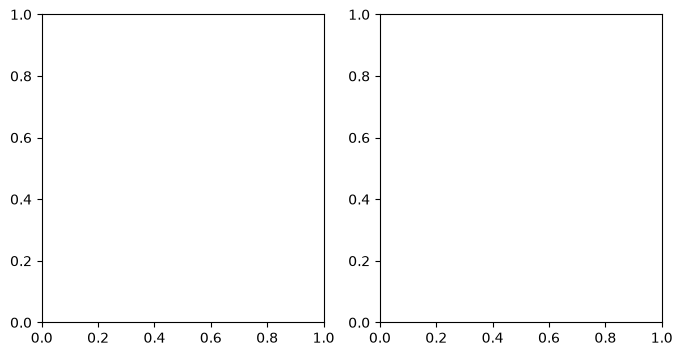

In [18]:
def display_random_chip(random_state):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    random_chip = train_meta.sample(random_state=random_state).iloc[0]
    ax[0].imshow(true_color_img(random_chip))
    ax[0].set_title(f"Chip {random_chip.chip_id}\n(Location: {random_chip.location})")
    label_im = Image.open(random_chip.label_path)
    ax[1].imshow(label_im)
    ax[1].set_title(f"Chip {random_chip.chip_id} label")

    plt.tight_layout()
    plt.show()

display_random_chip(1)
display_random_chip(9)
display_random_chip(40)

### Split the data

To train our model, we want to separate the data into a "training" set and a "validation" set. That way we'll have a portion of labelled data that was not used in model training, which can give us a more accurate sense of how our model will perform on the competition test data.

We have chosen the simplest route, and split our training chips randomly into 1% test, 29% validation and 70% training.

In [ ]:
import random

random.seed(42)  # set a seed for reproducibility

# put 1%, 29% and 70% of chips into the test, validation and training set respectively
chip_ids = train_meta.chip_id.unique().tolist()
n = len(chip_ids)

random.shuffle(chip_ids)
train_ids = chip_ids[:round(n * 0.70)]
val_ids = chip_ids[round(n * 0.70):round(n * 0.99)]
test_ids = chip_ids[round(n * 0.99):]

train = train_meta[train_meta.chip_id.isin(train_ids)].copy().reset_index(drop=True)
val = train_meta[train_meta.chip_id.isin(val_ids)].copy().reset_index(drop=True)
test = train_meta[train_meta.chip_id.isin(test_ids)].copy().reset_index(drop=True)

test.shape, val.shape, train.shape

### Build the model

In [ ]:
from benchmark.configs import Configs

config = Configs.balanced()

Each chip is imagery of a specific area captured at a specific point in time. There are four images associated with each chip in the competition data. Each image within a chip captures light from a different range of wavelengths, or "band". For example, the B02 band for each chip shows the strengh of visible blue light, which has a wavelength around 492 nanometers (nm). The bands provided are:

| Band | Description | Center wavelength |
|------|-------------|-------------------|
| B01 | Coastal aerosol | xxx nm |
| B02 | Blue visible light | 497 nm |
| B03 | Green visible light | 560 nm |
| B04 | Red visible light | 665 nm |
| B05/B08 | Near infrared light | 835 nm |
| B06 | SWIR1 | xxx nm |
| B07 | SWIR2 | xxx nm |
| B09 | Cirrus | xxx nm |
| B10 | Thermal infrared 1 | xxx nm |
| B11 | Thermal infrared 2 | xxx nm |

In [ ]:
# separate features from labels
feature_cols = ["chip_id"] + [f"{band}_path" for band in config.bands]

test_x = test[feature_cols].copy()
test_y = test[["chip_id", "label_path"]].copy()

val_x = val[feature_cols].copy()
val_y = val[["chip_id", "label_path"]].copy()

train_x = train[feature_cols].copy()
train_y = train[["chip_id", "label_path"]].copy()

### Fit the model

In [ ]:
import os
import pytorch_lightning as pl
import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

torch.set_float32_matmul_precision("high")

In [ ]:
from benchmark.dataset import CloudDataModule
from benchmark.models.cloud_model import CloudModel

cloud_datamodule = CloudDataModule(
    config=config,
    x_train=train_x,
    y_train=train_y,
    x_val=val_x,
    y_val=val_y,
    x_test=test_x,
    y_test=test_y,
)

cloud_model = CloudModel(
    config=config,
)

callbacks = [
    pl.callbacks.ModelCheckpoint(
        dirpath="checkpoints",
        filename="epoch{epoch:02d}-val_weighted_iou{val/weighted_iou:.4f}",
        auto_insert_metric_name=False,
        monitor="val/weighted_iou",
        mode="max",
        save_top_k=1,
        save_last=False,
        verbose=True,
    ),
    pl.callbacks.early_stopping.EarlyStopping(
        monitor="val/weighted_iou",
        min_delta=0.001,
        mode="max",
        patience=config.patience,
        verbose=True,
    ),
    pl.callbacks.LearningRateMonitor(logging_interval="step"),
]

trainer = pl.Trainer(
    accelerator="auto",
    devices="auto",
    # fast_dev_run=1,
    callbacks=callbacks,
    max_epochs=config.max_epochs,
    precision="bf16",
    enable_checkpointing=True,
    enable_progress_bar=True,
    enable_model_summary=True,
)

In [ ]:
# Fit the model
last_ckpt = Path("checkpoints/last.ckpt")
trainer.fit(
    model=cloud_model,
    datamodule=cloud_datamodule,
    # ckpt_path=last_ckpt if last_ckpt.exists() else None,
    # weights_only=False,
)

### Save the model

In [ ]:
# save the model
benchmark_dir = Path(config.model_name)
benchmark_assets_dir = benchmark_dir / "assets"
benchmark_assets_dir.mkdir(parents=True, exist_ok=True)

model_weight_path = benchmark_assets_dir / "cloud_model.pt"
torch.save(cloud_model.state_dict(), model_weight_path)

### Test the model

In [ ]:
# test the model
trainer.test(
    cloud_model,
    datamodule=cloud_datamodule,
    ckpt_path="best" if trainer.checkpoint_callback.best_model_path else None,
    weights_only=False,
)